h = 0.01
coefficient matrix =
[[ 1.    0.01]
 [-0.01  1.  ]]
eigenvalues = [1.+0.01j 1.-0.01j]
Solution may not be stable

h = 0.1
coefficient matrix =
[[ 1.   0.1]
 [-0.1  1. ]]
eigenvalues = [1.+0.1j 1.-0.1j]
Solution may not be stable

h = 0.5
coefficient matrix =
[[ 1.   0.5]
 [-0.5  1. ]]
eigenvalues = [1.+0.5j 1.-0.5j]
Solution may not be stable

h = 1.0
coefficient matrix =
[[ 1.  1.]
 [-1.  1.]]
eigenvalues = [1.+1.j 1.-1.j]
Solution may not be stable



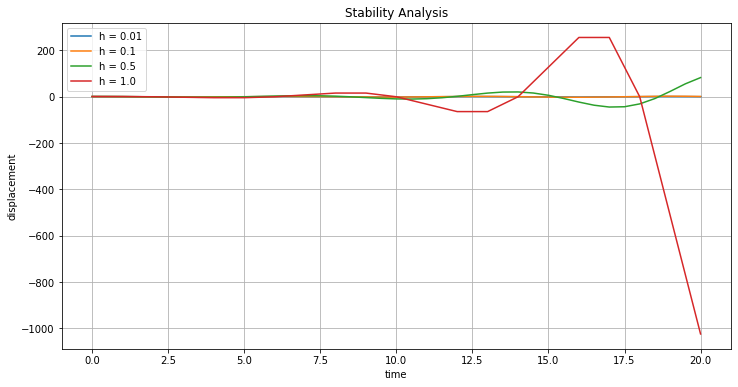

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
k = 1.0
h_values = [0.01, 0.1, 0.5, 1.0]
t_start = 0
t_end = 20
y_0 = 1.0
v_0 = 0.0

# function for Euler's Method
def euler_method(h, k, t_start, t_end, y_0, v_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))

    y_values[0] = y_0
    v_values[0] = v_0

    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]

        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)

    return t_values, y_values

plt.figure(figsize=(12, 6))

for h in h_values:
    A = np.array([[1, h],
                  [-h * k, 1]])

    eig = np.linalg.eigvals(A)

    print("h =", h)
    print("coefficient matrix =")
    print(A)
    print("eigenvalues =", eig)

    stable = True
    for val in eig:
        if abs(val) >= 1:
            stable = False

    if stable:
        print("Solution is stable")
    else:
        print("Solution may not be stable")

    print()

    t, y = euler_method(h, k, t_start, t_end, y_0, v_0)

    plt.plot(t, y, label="h = " + str(h))

plt.xlabel("time")
plt.ylabel("displacement")
plt.title("Stability Analysis")
plt.legend()
plt.grid(True)
plt.show()